# Pythia Attention-Sink Inference Ablation — Fixed Version

This notebook compares:

- normal full attention
- full attention with position 0 blocked
- full attention with positions 0–3 blocked
- recent-window attention with 0 sink tokens
- 1, 2, 3, or 4 preserved sink tokens under the same fixed attention budget
- replacement of the first four tokens with alternative content
- greedy generation under each attention policy

## Important setup note

This notebook intentionally pins a **legacy-compatible TransformerLens + Transformers pair** because the experiment uses `HookedTransformer` and `hook_attn_scores`.

If you already imported `transformer_lens` earlier in the current Colab session, run the install cell and then use:

**Runtime → Restart session**

After restarting, continue from the import cell. You do not need to rerun the install cell after the restart unless the imports fail.

## 1. Install compatible dependencies

In [1]:
# One install cell only. Do not separately upgrade transformer-lens or transformers later.
!pip -q install "transformer-lens==2.16.1" "transformers==4.51.3" "datasets>=2.18,<4" accelerate pandas matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependenc

## 2. Imports, version check, and experiment settings

In [2]:
import gc
import math
import random
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import transformers
import transformer_lens

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformer_lens import HookedTransformer

# ------------------------------------------------------------
# Version checks
# ------------------------------------------------------------
print("transformers:", transformers.__version__)

try:
    tl_version = importlib.metadata.version("transformer-lens")
except importlib.metadata.PackageNotFoundError:
    tl_version = "unknown"

print("transformer_lens:", tl_version)
print("torch:", torch.__version__)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Model names
# ------------------------------------------------------------
HF_MODEL_NAME = "EleutherAI/pythia-160m"
TL_MODEL_NAME = "pythia-160m"

# ------------------------------------------------------------
# Experiment settings
# ------------------------------------------------------------
WINDOW_SIZE = 64
SEQ_LEN = 192
N_SEQ = 16
MAX_NEW_TOKENS = 40

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False

try:
    torch.set_float32_matmul_precision("highest")
except Exception:
    pass

print("Device:", device)

transformers: 4.51.3
transformer_lens: 2.16.1
torch: 2.11.0+cu130
Device: cuda


## 3. Load Pythia safely

The notebook does **not** call `HookedTransformer.from_pretrained()` directly.

Instead:

1. Load Pythia with Hugging Face.
2. Add the legacy `rotary_pct` config field if necessary.
3. Convert that exact HF model to TransformerLens.
4. Keep everything in FP32 for numerical stability.

In [3]:
def _get_partial_rotary_factor(config):
    """Read the rotary fraction from either old or new HF GPT-NeoX configs."""
    if hasattr(config, "rotary_pct"):
        return float(config.rotary_pct)

    # Newer HF configs may store RoPE settings in rope_parameters / rope_scaling.
    for attr in ("rope_parameters", "rope_scaling"):
        obj = getattr(config, attr, None)
        if isinstance(obj, dict):
            value = obj.get("partial_rotary_factor", None)
            if value is not None:
                return float(value)

    # Pythia / GPT-NeoX uses 25% rotary dimensions.
    return 0.25


def load_pythia_tl(revision=None):
    hf_kwargs = {
        "torch_dtype": torch.float32,
    }

    if revision is not None:
        hf_kwargs["revision"] = revision

    print("Loading Hugging Face model...")

    hf_model = AutoModelForCausalLM.from_pretrained(
        HF_MODEL_NAME,
        **hf_kwargs,
    ).to(device).eval()

    # Compatibility bridge expected by TransformerLens 2.x.
    rotary_pct = _get_partial_rotary_factor(hf_model.config)
    hf_model.config.rotary_pct = rotary_pct

    print("rotary_pct:", hf_model.config.rotary_pct)

    print("Converting to TransformerLens...")

    try:
        tl_model = HookedTransformer.from_pretrained_no_processing(
            TL_MODEL_NAME,
            hf_model=hf_model,
            device=device,
            dtype=torch.float32,
        )
    except TypeError:
        # Compatibility with TL minor releases that do not accept dtype here.
        tl_model = HookedTransformer.from_pretrained_no_processing(
            TL_MODEL_NAME,
            hf_model=hf_model,
            device=device,
        )
        tl_model = tl_model.to(torch.float32)

    tl_model.eval()

    # Basic health checks.
    assert tl_model.cfg.n_layers > 0
    assert tl_model.cfg.n_heads > 0

    first_param = next(tl_model.parameters())
    print("TL parameter dtype:", first_param.dtype)

    del hf_model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return tl_model


model = load_pythia_tl()

print("\nModel loaded successfully")
print("Model:", TL_MODEL_NAME)
print("Layers:", model.cfg.n_layers)
print("Heads:", model.cfg.n_heads)
print("Context length:", model.cfg.n_ctx)

Loading Hugging Face model...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

rotary_pct: 0.25
Converting to TransformerLens...


tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model pythia-160m into HookedTransformer
TL parameter dtype: torch.float32

Model loaded successfully
Model: pythia-160m
Layers: 12
Heads: 12
Context length: 2048


## 4. Build the evaluation dataset

In [6]:
dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="test",
)

text = "\n".join(
    row["text"]
    for row in dataset
    if row["text"].strip()
)


tokenizer = model.tokenizer

encoded = tokenizer(
    text,
    add_special_tokens=False,
    truncation=False,
    return_tensors=None,
)

all_tokens = torch.tensor(
    encoded["input_ids"],
    dtype=torch.long,
)

print("Total available tokens:", len(all_tokens))

required_tokens = N_SEQ * SEQ_LEN

print("Required tokens:", required_tokens)

if len(all_tokens) < required_tokens:
    raise RuntimeError(
        f"Not enough tokens. "
        f"Available={len(all_tokens)}, "
        f"required={required_tokens}"
    )

chunks = []

for i in range(N_SEQ):
    start = i * SEQ_LEN
    end = start + SEQ_LEN

    chunk = all_tokens[start:end]

    chunks.append(chunk)

eval_tokens = torch.stack(chunks).to(device)

print("Evaluation tensor:", tuple(eval_tokens.shape))

print(
    "First 12 tokens:",
    model.to_str_tokens(eval_tokens[0, :12])
)

Total available tokens: 285831
Required tokens: 3072
Evaluation tensor: (16, 192)
First 12 tokens: [' =', ' Robert', ' B', 'oul', 'ter', ' =', ' \n\n', ' Robert', ' B', 'oul', 'ter', ' is']


# Part A — Attention visibility masks

For a query position \(q\), the mask determines which key positions \(k\) remain visible.

The streaming policy uses a fixed total budget \(W\):

\[
K\text{ sink positions} + (W-K)\text{ recent positions}
\]

In [7]:
def causal_mask(T):
    q = torch.arange(T)[:, None]
    k = torch.arange(T)[None, :]
    return k <= q


def full_minus_positions_mask(T, blocked_positions):
    """
    Standard causal attention except later queries cannot attend to selected
    absolute key positions.
    """
    allowed = causal_mask(T)

    for pos in blocked_positions:
        if 0 <= pos < T:
            allowed[pos + 1:, pos] = False

    # Every query must retain at least one valid key.
    allowed[torch.arange(T), torch.arange(T)] = True

    return allowed


def streaming_mask(T, window_size, n_sinks):
    """
    Fixed-budget logical attention:
        first n_sinks positions
        +
        most recent (window_size - n_sinks) positions.

    The current token counts as part of the recent window.
    """
    if not (0 <= n_sinks <= window_size):
        raise ValueError("n_sinks must satisfy 0 <= n_sinks <= window_size")

    allowed = torch.zeros((T, T), dtype=torch.bool)
    recent_budget = window_size - n_sinks

    for q in range(T):
        # Sink region.
        if n_sinks > 0:
            sink_end = min(n_sinks, q + 1)
            allowed[q, :sink_end] = True

        # Recent region.
        if recent_budget > 0:
            recent_start = max(n_sinks, q - recent_budget + 1)
            allowed[q, recent_start:q + 1] = True

        # Safety for very small budgets / early positions.
        allowed[q, q] = True

    allowed &= causal_mask(T)

    if not allowed.any(dim=1).all():
        raise RuntimeError("A query row has no visible key.")

    return allowed

## 5. Visualize the masks

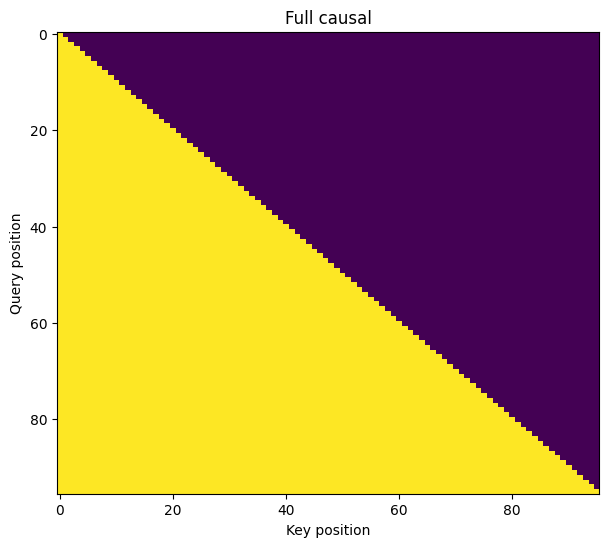

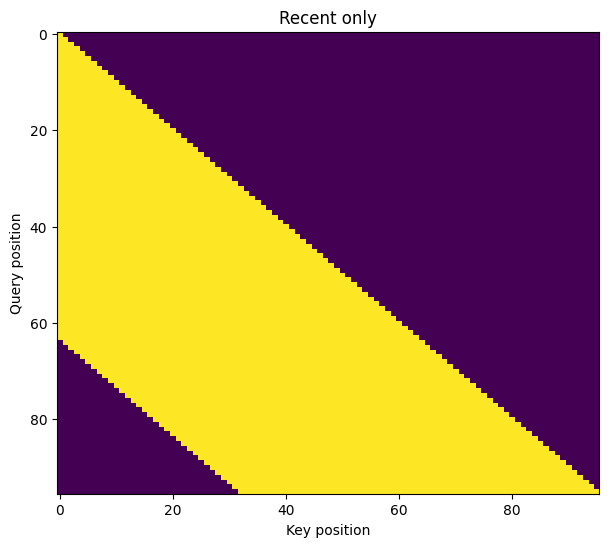

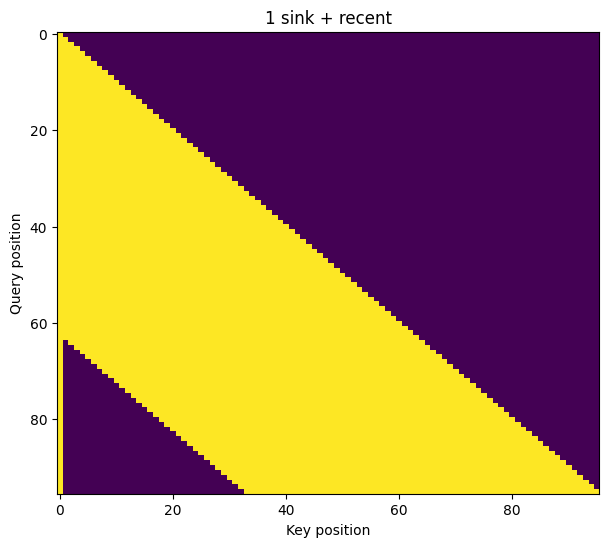

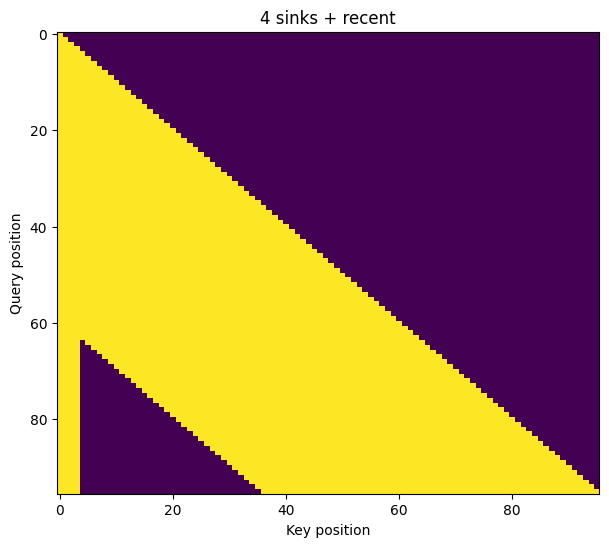

In [8]:
demo_T = 96

mask_examples = {
    "Full causal": causal_mask(demo_T),
    "Recent only": streaming_mask(demo_T, WINDOW_SIZE, n_sinks=0),
    "1 sink + recent": streaming_mask(demo_T, WINDOW_SIZE, n_sinks=1),
    "4 sinks + recent": streaming_mask(demo_T, WINDOW_SIZE, n_sinks=4),
}

for name, m in mask_examples.items():
    plt.figure(figsize=(7, 6))
    plt.imshow(m.numpy(), aspect="auto", interpolation="nearest")
    plt.xlabel("Key position")
    plt.ylabel("Query position")
    plt.title(name)
    plt.show()

## 6. Attention-score hook

In [9]:
def make_attention_mask_hook(allowed_mask):
    """
    Apply [Q,K] Boolean visibility mask to TL attention scores [B,H,Q,K].
    """
    allowed_mask = allowed_mask.to(torch.bool)

    def hook_fn(attn_scores, hook):
        q_len = attn_scores.shape[-2]
        k_len = attn_scores.shape[-1]

        m = allowed_mask[:q_len, :k_len].to(attn_scores.device)

        # Avoid in-place mutation of hook activations.
        out = attn_scores.clone()
        out = out.masked_fill(
            ~m[None, None, :, :],
            torch.finfo(out.dtype).min,
        )

        return out

    return hook_fn

## 7. Forward pass under a selected policy

In [10]:
@torch.no_grad()
def logits_with_mask(tokens, allowed_mask=None):
    if allowed_mask is None:
        logits = model(
            tokens,
            return_type="logits",
        )
    else:
        hook = make_attention_mask_hook(allowed_mask)

        hooks = [
            (
                f"blocks.{layer}.attn.hook_attn_scores",
                hook,
            )
            for layer in range(model.cfg.n_layers)
        ]

        logits = model.run_with_hooks(
            tokens,
            return_type="logits",
            fwd_hooks=hooks,
        )

    if not torch.isfinite(logits).all():
        raise RuntimeError("NaN/Inf detected in model logits.")

    return logits

## 8. NLL and perplexity

In [11]:
def sequence_nll(logits, tokens):
    pred = logits[:, :-1, :].float()
    target = tokens[:, 1:]

    loss = F.cross_entropy(
        pred.reshape(-1, pred.shape[-1]),
        target.reshape(-1),
        reduction="mean",
    )

    return float(loss.item())


def evaluate_policy(tokens, allowed_mask=None):
    logits = logits_with_mask(
        tokens,
        allowed_mask=allowed_mask,
    )

    nll = sequence_nll(logits, tokens)

    # Prevent Python overflow if an intervention catastrophically raises NLL.
    ppl = math.exp(nll) if nll < 80 else float("inf")

    return {
        "nll": nll,
        "ppl": ppl,
    }

## 9. Define the inference conditions

In [12]:
T = int(eval_tokens.shape[1])

policies = {
    "full":
        None,

    "full_minus_pos0":
        full_minus_positions_mask(T, [0]),

    "full_minus_pos0_to_3":
        full_minus_positions_mask(T, [0, 1, 2, 3]),

    "recent_only_64":
        streaming_mask(T, WINDOW_SIZE, n_sinks=0),

    "sink1_recent63":
        streaming_mask(T, WINDOW_SIZE, n_sinks=1),

    "sink2_recent62":
        streaming_mask(T, WINDOW_SIZE, n_sinks=2),

    "sink3_recent61":
        streaming_mask(T, WINDOW_SIZE, n_sinks=3),

    "sink4_recent60":
        streaming_mask(T, WINDOW_SIZE, n_sinks=4),
}

for name, mask in policies.items():
    print(
        f"{name:24s}",
        "full attention" if mask is None else tuple(mask.shape)
    )

full                     full attention
full_minus_pos0          (192, 192)
full_minus_pos0_to_3     (192, 192)
recent_only_64           (192, 192)
sink1_recent63           (192, 192)
sink2_recent62           (192, 192)
sink3_recent61           (192, 192)
sink4_recent60           (192, 192)


## 10. Evaluate all policies

In [13]:
results = []

for name, mask in policies.items():
    print("Running:", name)

    metrics = evaluate_policy(
        eval_tokens,
        allowed_mask=mask,
    )

    results.append({
        "policy": name,
        **metrics,
    })

results_df = pd.DataFrame(results)

baseline_nll = float(
    results_df.loc[
        results_df["policy"] == "full",
        "nll"
    ].iloc[0]
)

baseline_ppl = float(
    results_df.loc[
        results_df["policy"] == "full",
        "ppl"
    ].iloc[0]
)

results_df["delta_nll_vs_full"] = (
    results_df["nll"] - baseline_nll
)

results_df["ppl_ratio_vs_full"] = (
    results_df["ppl"] / baseline_ppl
)

display(results_df)

Running: full
Running: full_minus_pos0
Running: full_minus_pos0_to_3
Running: recent_only_64
Running: sink1_recent63
Running: sink2_recent62
Running: sink3_recent61
Running: sink4_recent60


,policy,nll,ppl,delta_nll_vs_full,ppl_ratio_vs_full
0,full,3.910854,49.941565,0.000000,1.000000
1,full_minus_pos0,3.937632,51.296966,0.026778,1.027140
2,full_minus_pos0_to_3,3.997358,54.454110,0.086505,1.090356
3,recent_only_64,4.482821,88.483933,0.571967,1.771749
4,sink1_recent63,4.047940,57.279355,0.137087,1.146928
5,sink2_recent62,4.046267,57.183594,0.135413,1.145010
6,sink3_recent61,4.044074,57.058302,0.133220,1.142501
7,sink4_recent60,4.042598,56.974184,0.131745,1.140817


## 11. Perplexity comparison

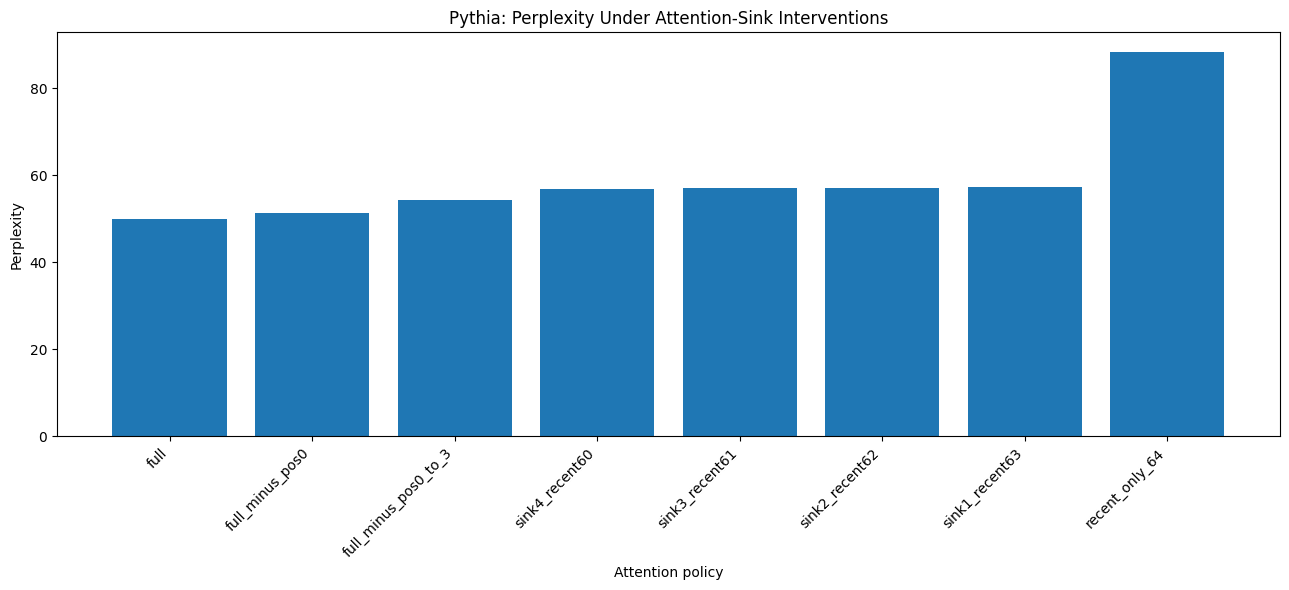

In [14]:
plot_df = results_df.sort_values("ppl")

plt.figure(figsize=(13, 6))
plt.bar(
    plot_df["policy"],
    plot_df["ppl"],
)
plt.ylabel("Perplexity")
plt.xlabel("Attention policy")
plt.title("Pythia: Perplexity Under Attention-Sink Interventions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Change in NLL versus full attention

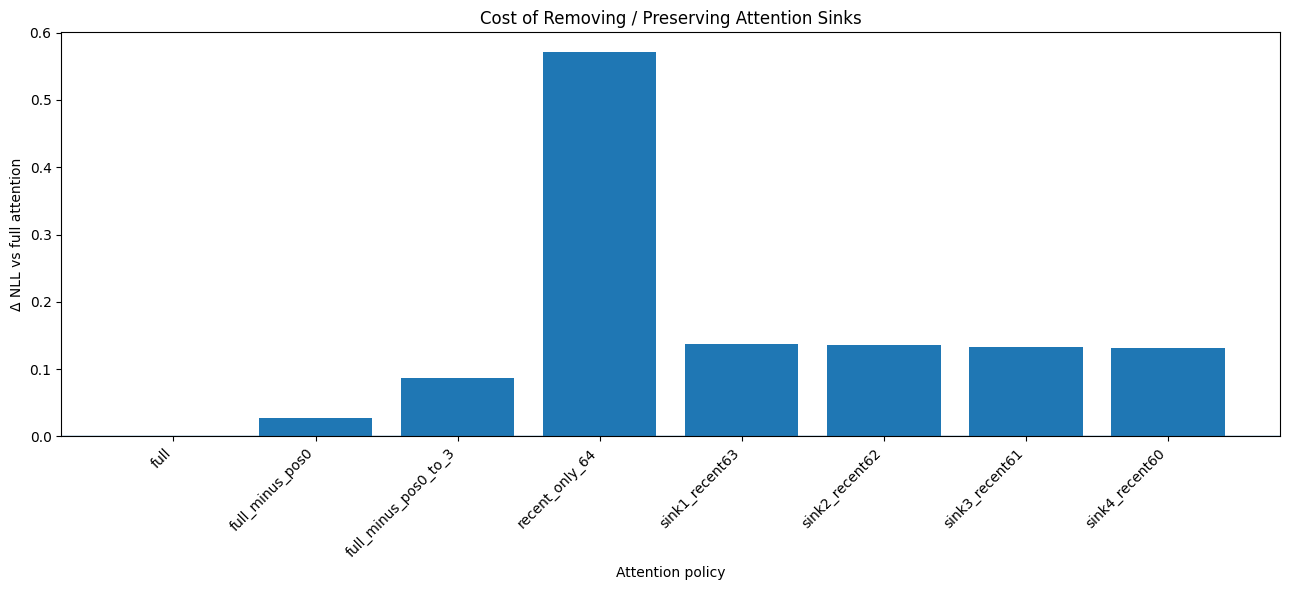

In [15]:
plt.figure(figsize=(13, 6))
plt.bar(
    results_df["policy"],
    results_df["delta_nll_vs_full"],
)
plt.axhline(0, linewidth=1)
plt.ylabel("Δ NLL vs full attention")
plt.xlabel("Attention policy")
plt.title("Cost of Removing / Preserving Attention Sinks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Fixed-budget sink-count ablation

,policy,nll,ppl,delta_nll_vs_full,ppl_ratio_vs_full,n_sinks,recent_budget
0,recent_only_64,4.482821,88.483933,0.571967,1.771749,0,64
1,sink1_recent63,4.047940,57.279355,0.137087,1.146928,1,63
2,sink2_recent62,4.046267,57.183594,0.135413,1.145010,2,62
3,sink3_recent61,4.044074,57.058302,0.133220,1.142501,3,61
4,sink4_recent60,4.042598,56.974184,0.131745,1.140817,4,60


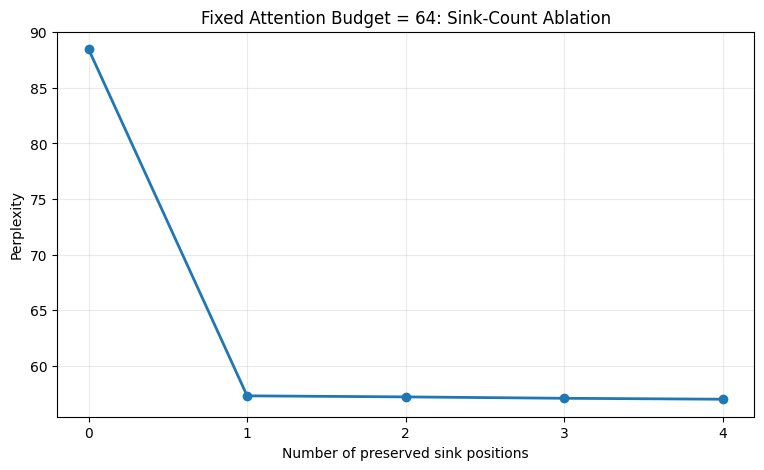

In [16]:
streaming_order = [
    "recent_only_64",
    "sink1_recent63",
    "sink2_recent62",
    "sink3_recent61",
    "sink4_recent60",
]

stream_df = (
    results_df
    .set_index("policy")
    .loc[streaming_order]
    .reset_index()
)

stream_df["n_sinks"] = [0, 1, 2, 3, 4]
stream_df["recent_budget"] = [
    WINDOW_SIZE - k
    for k in stream_df["n_sinks"]
]

display(stream_df)

plt.figure(figsize=(9, 5))
plt.plot(
    stream_df["n_sinks"],
    stream_df["ppl"],
    marker="o",
    linewidth=2,
)
plt.xlabel("Number of preserved sink positions")
plt.ylabel("Perplexity")
plt.title(
    f"Fixed Attention Budget = {WINDOW_SIZE}: Sink-Count Ablation"
)
plt.xticks([0, 1, 2, 3, 4])
plt.grid(alpha=0.25)
plt.show()

# Part B — Replace the first four tokens

We compare:

- original first four tokens
- repeated BOS/EOS token
- random vocabulary tokens
- four tokens copied from the middle
- shuffled original first four tokens

In [17]:
def replace_first_four(batch_tokens, mode):
    x = batch_tokens.clone()

    if mode == "original":
        return x

    if mode == "repeat_bos":
        bos = getattr(model.tokenizer, "bos_token_id", None)

        if bos is None:
            bos = getattr(model.tokenizer, "eos_token_id", None)

        if bos is None:
            raise RuntimeError("Tokenizer exposes neither BOS nor EOS token ID.")

        x[:, :4] = int(bos)
        return x

    if mode == "random_tokens":
        vocab_size = int(model.cfg.d_vocab)

        g = torch.Generator(device="cpu")
        g.manual_seed(SEED)

        rand = torch.randint(
            0,
            vocab_size,
            (x.shape[0], 4),
            generator=g,
            dtype=x.dtype,
        ).to(x.device)

        x[:, :4] = rand
        return x

    if mode == "copy_middle":
        source_start = min(32, x.shape[1] - 8)
        x[:, :4] = x[:, source_start:source_start + 4].clone()
        return x

    if mode == "shuffle_first4":
        perm = torch.tensor(
            [2, 0, 3, 1],
            device=x.device,
        )

        original4 = x[:, :4].clone()
        x[:, :4] = original4[:, perm]
        return x

    raise ValueError(f"Unknown replacement mode: {mode}")


replacement_modes = [
    "original",
    "repeat_bos",
    "random_tokens",
    "copy_middle",
    "shuffle_first4",
]

replacement_batches = {
    mode: replace_first_four(eval_tokens, mode)
    for mode in replacement_modes
}

for mode, batch in replacement_batches.items():
    print("\n" + mode)
    print(model.to_str_tokens(batch[0, :12]))


original
[' =', ' Robert', ' B', 'oul', 'ter', ' =', ' \n\n', ' Robert', ' B', 'oul', 'ter', ' is']

repeat_bos
['<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', 'ter', ' =', ' \n\n', ' Robert', ' B', 'oul', 'ter', ' is']

random_tokens
[' advertis', ' ant', 'Control', ' Webster', 'ter', ' =', ' \n\n', ' Robert', ' B', 'oul', 'ter', ' is']

copy_middle
[' television', ' series', ' The', ' Bill', 'ter', ' =', ' \n\n', ' Robert', ' B', 'oul', 'ter', ' is']

shuffle_first4
[' B', ' =', 'oul', ' Robert', 'ter', ' =', ' \n\n', ' Robert', ' B', 'oul', 'ter', ' is']


## 14. Evaluate token replacements

In [18]:
replacement_results = []

sink4_mask = streaming_mask(
    T,
    WINDOW_SIZE,
    n_sinks=4,
)

for mode, batch in replacement_batches.items():
    print("Running replacement:", mode)

    full_metrics = evaluate_policy(
        batch,
        allowed_mask=None,
    )

    replacement_results.append({
        "replacement": mode,
        "attention_policy": "full",
        **full_metrics,
    })

    sink_metrics = evaluate_policy(
        batch,
        allowed_mask=sink4_mask,
    )

    replacement_results.append({
        "replacement": mode,
        "attention_policy": "sink4_recent60",
        **sink_metrics,
    })

replacement_df = pd.DataFrame(replacement_results)

display(replacement_df)

Running replacement: original
Running replacement: repeat_bos
Running replacement: random_tokens
Running replacement: copy_middle
Running replacement: shuffle_first4


,replacement,attention_policy,nll,ppl
0,original,full,3.910854,49.941565
1,original,sink4_recent60,4.042598,56.974184
2,repeat_bos,full,4.153260,63.641147
3,repeat_bos,sink4_recent60,4.268711,71.429510
4,random_tokens,full,4.574120,96.942650
5,random_tokens,sink4_recent60,4.713699,111.463687
6,copy_middle,full,3.971540,53.066176
7,copy_middle,sink4_recent60,4.103939,60.578411
8,shuffle_first4,full,4.011869,55.250034
9,shuffle_first4,sink4_recent60,4.144897,63.111120


## 15. Replacement-token perplexity

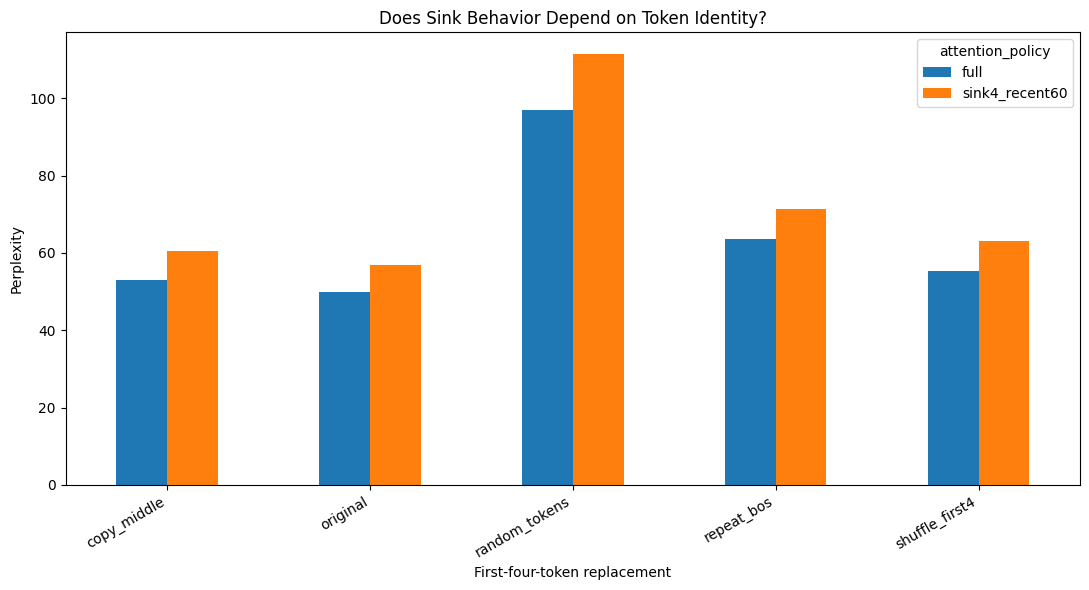

In [19]:
pivot = replacement_df.pivot(
    index="replacement",
    columns="attention_policy",
    values="ppl",
)

pivot.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.ylabel("Perplexity")
plt.xlabel("First-four-token replacement")
plt.title("Does Sink Behavior Depend on Token Identity?")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Part C — Qualitative autoregressive generation

In [20]:
def policy_mask_for_length(policy_name, T):
    if policy_name == "full":
        return None

    if policy_name == "full_minus_pos0":
        return full_minus_positions_mask(T, [0])

    if policy_name == "full_minus_pos0_to_3":
        return full_minus_positions_mask(T, [0, 1, 2, 3])

    mapping = {
        "recent_only_64": 0,
        "sink1_recent63": 1,
        "sink2_recent62": 2,
        "sink3_recent61": 3,
        "sink4_recent60": 4,
    }

    if policy_name in mapping:
        return streaming_mask(
            T,
            WINDOW_SIZE,
            n_sinks=mapping[policy_name],
        )

    raise ValueError(f"Unknown policy: {policy_name}")

In [23]:
@torch.no_grad()
def generate_with_policy(
    prompt,
    policy_name,
    max_new_tokens=MAX_NEW_TOKENS,
):
    tokens = model.to_tokens(
        prompt,
        prepend_bos=True,
    ).to(device)

    for _ in range(max_new_tokens):
        T_now = int(tokens.shape[1])

        if T_now >= model.cfg.n_ctx:
            break

        mask = policy_mask_for_length(
            policy_name,
            T_now,
        )

        logits = logits_with_mask(
            tokens,
            allowed_mask=mask,
        )

        next_token = logits[:, -1, :].argmax(
            dim=-1,
            keepdim=True,
        )

        tokens = torch.cat(
            [tokens, next_token],
            dim=1,
        )

    return model.to_string(tokens[0])

In [26]:
# ------------------------------------------------------------
# Policy mask
# ------------------------------------------------------------
def policy_mask_for_length(policy_name, T):
    if policy_name == "full":
        return None

    if policy_name == "full_minus_pos0":
        return full_minus_positions_mask(T, [0])

    if policy_name == "full_minus_pos0_to_3":
        return full_minus_positions_mask(T, [0, 1, 2, 3])

    mapping = {
        "recent_only_64": 0,
        "sink1_recent63": 1,
        "sink2_recent62": 2,
        "sink3_recent61": 3,
        "sink4_recent60": 4,
    }

    if policy_name in mapping:
        return streaming_mask(
            T,
            WINDOW_SIZE,
            n_sinks=mapping[policy_name],
        )

    raise ValueError(f"Unknown policy: {policy_name}")


# ------------------------------------------------------------
# Greedy generation
# ------------------------------------------------------------
@torch.no_grad()
def generate_with_policy(
    prompt,
    policy_name,
    max_new_tokens=150,
):
    tokens = model.to_tokens(
        prompt,
        prepend_bos=True,
    ).to(device)

    prompt_len = tokens.shape[1]

    print(
        f"{policy_name:24s} | "
        f"prompt={prompt_len} tokens | "
        f"window={WINDOW_SIZE}"
    )

    generated_token_ids = []

    for step in range(max_new_tokens):

        T_now = int(tokens.shape[1])

        if T_now >= model.cfg.n_ctx:
            print(
                f"Stopped at step {step}: "
                f"context limit {model.cfg.n_ctx}"
            )
            break

        mask = policy_mask_for_length(
            policy_name,
            T_now,
        )

        logits = logits_with_mask(
            tokens,
            allowed_mask=mask,
        )

        next_token = logits[:, -1, :].argmax(
            dim=-1,
            keepdim=True,
        )

        generated_token_ids.append(
            int(next_token.item())
        )

        tokens = torch.cat(
            [tokens, next_token],
            dim=1,
        )

    full_text = model.to_string(tokens[0])

    continuation = model.to_string(
        torch.tensor(
            generated_token_ids,
            device=device,
            dtype=torch.long
        )
    )

    return {
        "full_text": full_text,
        "continuation": continuation,
        "prompt_tokens": prompt_len,
        "generated_tokens": len(generated_token_ids),
        "total_tokens": tokens.shape[1],
    }


# ------------------------------------------------------------
# LONG prompt
# Aim for > 64 tokens so the recent-window policies are active
# immediately.
# ------------------------------------------------------------
generation_prompt = """
Artificial intelligence has developed rapidly over several decades.
Early systems relied heavily on manually designed rules and symbolic
representations. As larger datasets became available, statistical machine
learning became increasingly important. Neural networks later enabled models
to learn complex representations directly from data.

Transformer architectures changed natural language processing by replacing
recurrent computation with self-attention. In a transformer, each token can
compare its query representation against key representations belonging to
other tokens in the sequence. The resulting attention weights determine how
value representations are combined.

Autoregressive language models generate text one token at a time. During
generation, the key and value representations of previous tokens are normally
stored in a KV cache. This avoids recomputing all previous states after every
newly generated token. However, the size of the KV cache grows with sequence
length, creating substantial memory requirements for long-context inference.

One simple approach is sliding-window attention, where only a fixed number of
recent tokens remain available. Although this reduces memory use, researchers
have observed that removing the earliest tokens can severely degrade model
quality. Some of these early positions receive unexpectedly large amounts of
attention from later tokens even when they do not appear semantically important.

These positions are known as attention sinks. A streaming inference strategy
can preserve a small number of initial sink positions while using the rest of
the memory budget for recent tokens. This creates an important experimental
question: under the same total attention budget, does preserving one, two,
three, or four early sink positions improve language-model behavior compared
with keeping only the most recent tokens?

The following discussion examines this question by comparing different
attention-retention policies.
"""


# ------------------------------------------------------------
# Check prompt length first
# ------------------------------------------------------------
prompt_tokens = model.to_tokens(
    generation_prompt,
    prepend_bos=True,
)

print(
    "Prompt token count:",
    prompt_tokens.shape[1]
)

print(
    "Window size:",
    WINDOW_SIZE
)

if prompt_tokens.shape[1] <= WINDOW_SIZE:
    print(
        "WARNING: prompt should ideally be longer than WINDOW_SIZE."
    )
else:
    print(
        "Good: sliding-window policies are already active at generation step 1."
    )


# ------------------------------------------------------------
# Policies
# ------------------------------------------------------------
generation_policies = [
    "full",
    "full_minus_pos0",
    "full_minus_pos0_to_3",
    "recent_only_64",
    "sink1_recent63",
    "sink2_recent62",
    "sink3_recent61",
    "sink4_recent60",
]


# ------------------------------------------------------------
# Run generation
# ------------------------------------------------------------
generated = {}

for policy in generation_policies:

    print("\n" + "=" * 100)
    print("POLICY:", policy)
    print("=" * 100)

    result = generate_with_policy(
        generation_prompt,
        policy,
        max_new_tokens=150,
    )

    generated[policy] = result

    print("\nGENERATED CONTINUATION ONLY:\n")
    print(result["continuation"])

    print("\nStatistics:")
    print(
        "Prompt tokens:",
        result["prompt_tokens"]
    )
    print(
        "Generated tokens:",
        result["generated_tokens"]
    )
    print(
        "Total tokens:",
        result["total_tokens"]
    )

Prompt token count: 360
Window size: 64
Good: sliding-window policies are already active at generation step 1.

POLICY: full
full                     | prompt=360 tokens | window=64

GENERATED CONTINUATION ONLY:


What is the best way to preserve early sink positions?

The best way to preserve early sink positions is to use a
streaming inference strategy. The streaming inference strategy is a
method that uses a stream of tokens to generate a sequence of tokens. The
sequence of tokens is then compared against the sequence of tokens in the
sequence. The stream is then compared against the sequence of tokens in the
sequence. The stream is compared against the sequence of tokens in the
sequence. The stream is compared against the sequence of tokens in the
sequence.

What is the best way to preserve early sink positions?

The best way to preserve early sink positions is to use a
streaming inference strategy. The stream

Statistics:
Prompt tokens: 360
Generated tokens: 150
Total tokens: 510
